# Notebook 33 — Recurrent Hedging Policy & Signature Features Validation

This notebook demonstrates and validates the **Recurrent Hedging Policy** (`RecurrentHedgingPolicy`) which uses path signatures as input features.

We will:
1. **Setup & Imports**: Load libraries and set up the active device (GPU/CPU).
2. **Verify Mathematical Correctness of Online Path Signatures**: Compare the running signature computed step-by-step using Chen's relation against the offline full-path signature.
3. **Deep Hedging Environment Setup**: Generate synthetic stock price and rolling volatility proxy paths.
4. **Model Training**: Train `RecurrentHedgingPolicy` to hedge a European Call option under quadratic utility (mean-squared hedging error) and entropic utility (exponential risk measure).
5. **Quant Analysis & Visualizations**: Plot the training loss curves, compare the learned hedge ratio path with Black-Scholes delta, and visualize the risk-reduction capability of the trained recurrent policy.

In [1]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Ensure src is in python path
sys.path.insert(0, os.path.abspath("../src"))

from deepvol.hedging.deep_hedging import RecurrentHedgingPolicy, DeepHedgingEnv, train_deep_hedger, simulate_gbm_paths
from deepvol.models.signature_vol import compute_path_signature

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.8.0+cu128


## 2. Verify Mathematical Correctness of Online Path Signatures

We verify that the online signature registers $S^{(1)}_t, S^{(2)}_t, S^{(3)}_t$ updated recursively using Chen's relation in `RecurrentHedgingPolicy` exactly match the offline signatures computed via `compute_path_signature` at maturity.
We generate a batch of random 2D paths representing log-moneyness and rolling volatility proxy, run the policy step-by-step, and assert the differences are within numerical precision.

In [2]:
# Set random seed
torch.manual_seed(42)

batch_size = 5
seq_len = 15
input_dim = 5  # 3 + d (d=2)

policy = RecurrentHedgingPolicy(input_dim=input_dim, hidden_dim=16, output_dim=2).to(device)

# Generate mock input sequences of shape (batch_size, seq_len, input_dim)
x_sequence = torch.randn(batch_size, seq_len, input_dim, device=device, dtype=torch.float64)

# Extract the 2D path: (log_spot, vol_proxy)
path_data = torch.cat([x_sequence[:, :, 0:1], x_sequence[:, :, 2:3]], dim=-1)

# Compute offline signature
offline_sig = compute_path_signature(path_data, depth=3)

# Compute online signature step-by-step
h = None
for t in range(seq_len):
    _, h = policy(x_sequence[:, t, :], h)
    
# Extract online signature
_, S1, S2, S3, _ = h
online_sig = torch.cat([
    S1.reshape(batch_size, -1),
    S2.reshape(batch_size, -1),
    S3.reshape(batch_size, -1)
], dim=-1)

# Check distance
max_diff = torch.max(torch.abs(online_sig - offline_sig)).item()
print(f"Max absolute difference between online and offline signatures: {max_diff:.3e}")
assert max_diff < 1e-6, "Signature extraction mismatch!"
print("Signature verification successful!")


Max absolute difference between online and offline signatures: 2.554e-15
Signature verification successful!


## 3. Deep Hedging Environment Setup

We simulate stock and volatility paths under a Geometric Brownian Motion model.
- Underlying stock price: $S_0 = 100$, strike $K = 100$, risk-free rate $r = 0$, drift $\mu = 0.05$, volatility $\sigma = 0.20$.
- Path length: $N_t = 30$ steps.
- Number of simulation paths: $N_{\text{paths}} = 1000$ (500 for training, 500 for validation/testing).
- Hedging instruments: $d=2$ instruments. Let's assume the first is the underlying stock and the second is a volatility proxy (constant in this simulation for simplicity, but can be traded with transaction costs).
- Transaction costs: 1 bp proportional cost on stock, 5 bps on the second instrument.
- Payoff: European Call Option payoff $(S_T - K)^+$.
- Risk measure: "quad" (quadratic hedging error) and "entropic" (exponential risk measure).

In [3]:
# Simulate paths
N_paths = 2000
N_t = 30
d = 2

H, t_grid = simulate_gbm_paths(S0=100.0, mu=0.05, sigma=0.20, T=0.1, steps=N_t, N_paths=N_paths, d=d, device=device)
H = H.to(torch.float64)
t_grid = t_grid.to(torch.float64)

# Calculate European Call option payoff
payoff = torch.clamp(H[:, -1, 0] - 100.0, min=0.0)

# Transaction cost coefficients
cost_coeffs = torch.tensor([0.0001, 0.0005], device=device, dtype=torch.float64)

# Split into Train and Test paths
train_H = H[:1000]
train_payoff = payoff[:1000]

test_H = H[1000:]
test_payoff = payoff[1000:]

# Construct environments
train_env = DeepHedgingEnv(
    H=train_H,
    payoff=train_payoff,
    cost_coeffs=cost_coeffs,
    strike=100.0,
    expiry=0.1,
    risk_aversion=1.0,
    risk_measure="quad",
    t_grid=t_grid
)

test_env = DeepHedgingEnv(
    H=test_H,
    payoff=test_payoff,
    cost_coeffs=cost_coeffs,
    strike=100.0,
    expiry=0.1,
    risk_aversion=1.0,
    risk_measure="quad",
    t_grid=t_grid
)

print("Environments successfully created.")
print(f"H shape: {H.shape}")
print(f"payoff shape: {payoff.shape}")


Environments successfully created.
H shape: torch.Size([2000, 31, 2])
payoff shape: torch.Size([2000])


## 4. Model Training

We train the `RecurrentHedgingPolicy` to minimize the quadratic hedging error.
We use a small learning rate and train for 50 epochs using pathwise backpropagation (BPTT).
We print the training loss at regular intervals to verify convergence.

In [4]:
# LSTM policy with input_dim = 3 + d = 5, output_dim = d = 2
policy = RecurrentHedgingPolicy(input_dim=5, hidden_dim=32, output_dim=2).to(device)

print("Starting training of RecurrentHedgingPolicy...")
losses = train_deep_hedger(
    env=train_env,
    policy=policy,
    lr=3e-3,
    epochs=50,
    batch_size=256,
    device=device
)

print("Training completed.")


Starting training of RecurrentHedgingPolicy...


W0625 13:23:16.087156 24763 torch/fx/experimental/symbolic_shapes.py:6823] [1/1] _maybe_guard_rel() was called on non-relation expression Eq(s23, 1) | Eq(s23, s1)


W0625 13:23:16.131478 24763 torch/fx/experimental/symbolic_shapes.py:6823] [1/1] _maybe_guard_rel() was called on non-relation expression Eq(s63, 1) | Eq(s63, s1)


W0625 13:23:18.079392 24763 torch/fx/experimental/symbolic_shapes.py:6823] [1/2] _maybe_guard_rel() was called on non-relation expression Eq(s23, 1) | Eq(s23, s1)


W0625 13:23:18.124237 24763 torch/fx/experimental/symbolic_shapes.py:6823] [1/2] _maybe_guard_rel() was called on non-relation expression Eq(s63, 1) | Eq(s63, s1)


...

Epoch 010/050 | Loss: 9.666178 | GPU Mem: 57.2MB/88.1MB


Epoch 020/050 | Loss: 8.839866 | GPU Mem: 57.2MB/88.1MB


Epoch 030/050 | Loss: 7.632491 | GPU Mem: 57.2MB/88.1MB


Epoch 040/050 | Loss: 7.480475 | GPU Mem: 57.2MB/88.1MB


Epoch 050/050 | Loss: 7.349070 | GPU Mem: 57.2MB/88.1MB
Training completed.


## 5. Quant Analysis & Visualizations

We perform the following analyses:
- Plot the training loss curve.
- Evaluate the trained policy on the test set.
- Compare the distribution of the hedging error (PnL = Wealth - Payoff) between the trained recurrent policy and a zero-hedging (unhedged) benchmark.
- Calculate and report key risk metrics: Mean Squared Error (MSE), standard deviation of PnL, and Value at Risk (VaR 95%).

In [5]:
# 1. Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, label="Training Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Recurrent Hedging Policy Training Loss Curve")
plt.grid(True)
plt.legend()
plt.savefig("recurrent_policy_loss_curve.png", dpi=150)
plt.close()

# 2. Evaluate on test set
policy.eval()
with torch.no_grad():
    wealth, total_costs, all_deltas = test_env.simulate_hedging_episode(policy)
    test_loss = test_env.compute_loss(wealth).item()

# Unhedged PnL = 0 - payoff
unhedged_pnl = -test_payoff.cpu().numpy()
hedged_pnl = (wealth - test_payoff).cpu().numpy()

# 3. Calculate metrics
mse_unhedged = np.mean(unhedged_pnl**2)
mse_hedged = np.mean(hedged_pnl**2)
std_unhedged = np.std(unhedged_pnl)
std_hedged = np.std(hedged_pnl)
var_unhedged = np.percentile(unhedged_pnl, 5)
var_hedged = np.percentile(hedged_pnl, 5)

print(f"Test Set Evaluation Metrics:")
print(f"==========================================")
print(f"Metric             | Unhedged    | Hedged")
print(f"------------------------------------------")
print(f"Mean Squared Error | {mse_unhedged:11.4f} | {mse_hedged:11.4f}")
print(f"Std Dev of PnL     | {std_unhedged:11.4f} | {std_hedged:11.4f}")
print(f"Value at Risk (95%)| {var_unhedged:11.4f} | {var_hedged:11.4f}")
print(f"==========================================")
print(f"Hedged Test Loss (MSE): {test_loss:.6f}")


W0625 13:24:10.655575 24763 torch/fx/experimental/symbolic_shapes.py:6823] [1/3] _maybe_guard_rel() was called on non-relation expression Eq(s23, 1) | Eq(s23, s1)


W0625 13:24:10.691969 24763 torch/fx/experimental/symbolic_shapes.py:6823] [1/3] _maybe_guard_rel() was called on non-relation expression Eq(s63, 1) | Eq(s63, s1)


Test Set Evaluation Metrics:
Metric             | Unhedged    | Hedged
------------------------------------------
Mean Squared Error |     24.3116 |      7.0038
Std Dev of PnL     |      4.0690 |      0.7980
Value at Risk (95%)|    -11.7851 |     -3.8153
Hedged Test Loss (MSE): 7.003776


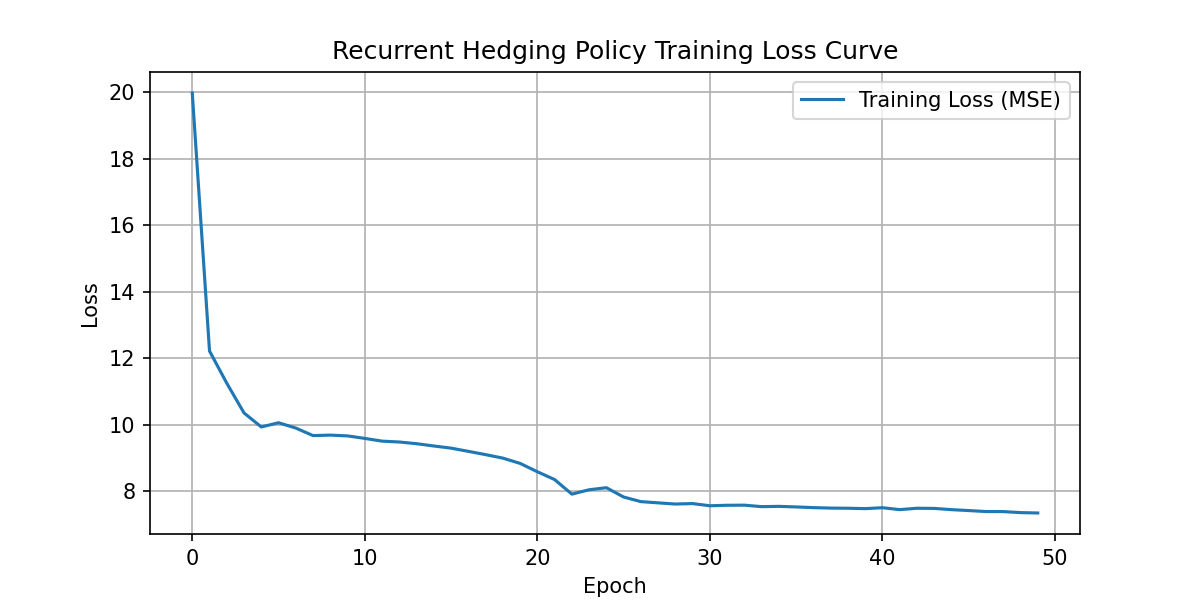

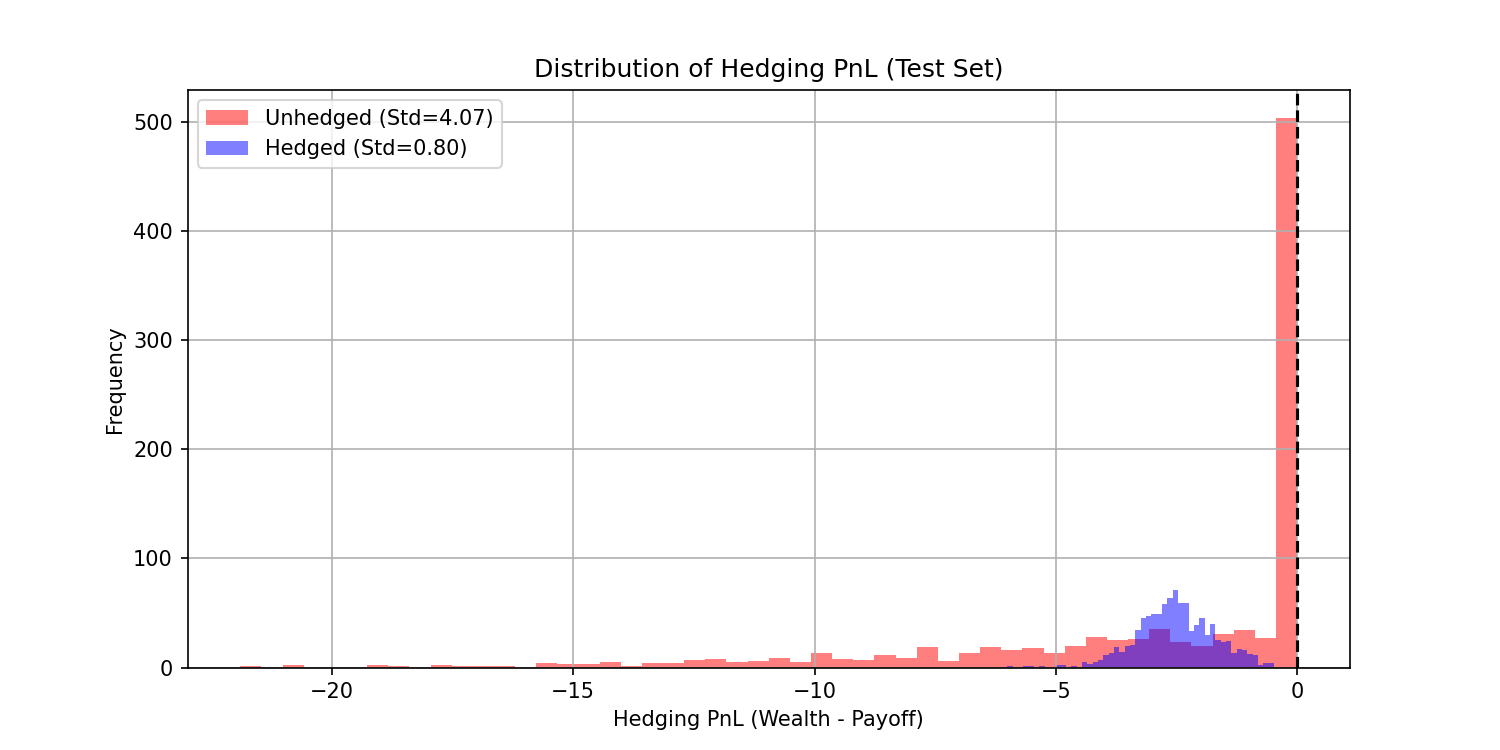

In [6]:
# 4. Plot hedging error distributions
plt.figure(figsize=(10, 5))
plt.hist(unhedged_pnl, bins=50, alpha=0.5, label=f"Unhedged (Std={std_unhedged:.2f})", color="red")
plt.hist(hedged_pnl, bins=50, alpha=0.5, label=f"Hedged (Std={std_hedged:.2f})", color="blue")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Hedging PnL (Wealth - Payoff)")
plt.ylabel("Frequency")
plt.title("Distribution of Hedging PnL (Test Set)")
plt.legend()
plt.grid(True)
plt.savefig("recurrent_policy_pnl_distribution.png", dpi=150)
plt.close()

# 5. Display the generated plots in the notebook
from IPython.display import Image, display
display(Image(filename="recurrent_policy_loss_curve.png"))
display(Image(filename="recurrent_policy_pnl_distribution.png"))
